In [59]:
import numpy as np

def setup_parameters(lam, th=0.005, N=5, zeta_1=0.0, M_inf = 25):

    N = N # Number of modes
    M_inf = M_inf # Mach number
    mu = 2.37e-9 # Dynamic viscosity (kg/m/s)
    Theta = 3.5 # Temperature Ratio
    th = th
    alpha_m = 0.0
    gamma = 1.4
    alpha_k_1 = 1.0
    alpha_k_2 = 1.0
    Rx = 0.0
    Pz = 0.0
    nu = 0.3
    zeta_1 = zeta_1

    Px = lam * (1-alpha_m) / np.sqrt(2*np.pi*gamma)
    alpha_k = alpha_k_1 * alpha_k_2 / (alpha_k_1 + alpha_k_2 - alpha_k_1 * alpha_k_2)
    A1 = -lam/np.sqrt(2*np.pi*gamma) * (2*(1+alpha_m) + (1-alpha_m)*(np.pi/2*np.sqrt(Theta)-1))
    A2 = -lam/np.sqrt(2*np.pi*gamma) * (2*(1+alpha_m) + np.pi/2*(1-alpha_m)*np.sqrt(Theta)) * np.sqrt(mu/(lam*M_inf))
    A3 = lam * M_inf / 2 * th * (1-alpha_m)
    A4 = A3 * np.sqrt(mu/(lam*M_inf))
    
    params = {
        'N': N,
        'M_inf': M_inf,
        'mu': mu,
        'Theta': Theta,
        'th': th,
        'alpha_m': alpha_m,
        'gamma': gamma,
        'alpha_k_1': alpha_k_1,
        'alpha_k_2': alpha_k_2,
        'Rx': Rx,
        'Px': Px,
        'Pz': Pz,
        'nu': nu,
        'zeta_1': zeta_1,
        'alpha_k': alpha_k,
        'A1': A1,
        'A2': A2,
        'A3': A3,
        'A4': A4
    }
    return params

def flutter_model(t, y, params):
    N = params['N']
    ydot = np.zeros_like(y)
    
    for i in range(N):
        ydot[i] = y[N + i] 
        ydot[N + i] = lhs(i, y, params)

    return ydot

def lhs(i, y, params):
    # Unpack parameters
    n = i + 1 # Mode number starts from 1
    N = params['N']

    # Calculate Output
    output = 0.0
    output += an(n, params) * y[i] # an(n) * q_n
    for m in range(1, N+1):
        if m != n:
            output += bnm(n,m,params) * y[m-1] # bnm(n,m) * q_m
    for r in range(1, N+1):
        output += anr_s(n,r,params) * y[r-1]**2 * y[i]
        output += anr_ss(n,r,params) * y[r-1] * y[i]
        output += anr_sss(n,r,params) * y[N+r-1] * y[i]
    for m in range(1, N+1):
        for r in range(1, N+1):
            if m != n:
                output += bnmr_s(n,m,r,params) * y[r-1] * y[m-1]
    output += cn(n, params) * y[N + i] # cn(n) * qdot_n

    for m in range(1, N+1):
        if m != n:
            output += cnm_s(n,m,params) * y[N + m - 1] # cnm_s(n,m) * qdot_m
    output -= dn(n, params) # dn(n)
    output *= -2
    return output

def an(n, params):
    Rx = params['Rx']
    A3 = params['A3']
    alpha_k = params['alpha_k']
    alpha_k_1 = params['alpha_k_1']
    Px = params['Px']
    output = ((n*np.pi)**2 + Rx + A3/2 + 1/2*(1-2*alpha_k/alpha_k_1+alpha_k)*Px)*(n*np.pi)**2/2
    return output

def anr_s(n, r, params):
    alpha_k = params['alpha_k']
    nu = params['nu']
    output = 3*alpha_k*(1-nu**2)*(r*np.pi)**2*(n*np.pi)**2/2
    return output

def anr_ss(n, r, params):
    alpha_k = params['alpha_k']
    A3 = params['A3']
    output = alpha_k*A3*(1-(-1)**r)/(r*np.pi)*(n*np.pi)**2/2
    return output

def anr_sss(n, r, params):
    A4 = params['A4']
    alpha_k = params['alpha_k']
    alpha_k_1 = params['alpha_k_1']
    output = -A4*((1-alpha_k)*(-1)**r/(r*np.pi) - alpha_k * (alpha_k_1 - 1) / alpha_k_1 * (1-(-1)**r) / (n*np.pi))**2/2
    return output

def bnm(n, m, params):
    Px = params['Px']
    A1 = params['A1']
    output = m*n/(n**2 - m**2) * ((n**2+m**2)/(n**2-m**2)*Px-A1)*(1-(-1)**(m+n))
    return output

def bnmr_s(n, m, r, params):
    A3 = params['A3']
    if n == 0 or m == 0 or r == 0:
        return 0.0
    else:
        if (m**2+n**2-r**2)**2-4*m**2*n**2 == 0:
            return 0.0
        output = np.pi*A3*m*n*r*(m**2+n**2-r**2)/ ((m**2+n**2-r**2)**2-4*m**2*n**2) * (1-(-1)**(m+n+r))
        return output

def cn(n, params):
    A2 = params['A2']
    zeta_1 = params['zeta_1']
    output = -A2/2 + np.pi**2*zeta_1
    return output

def cnm_s(n, m, params):
    A4 = params['A4']
    output = -A4/2*m*n/(n**2-m**2)*(1-(-1)**(m+n))
    return output

def dn(n, params):
    Pz = params['Pz']
    output = Pz*(1-(-1)**n)/(n*np.pi)
    return output

Running simulation for parameter set 1 with zeta_1 = 0.0


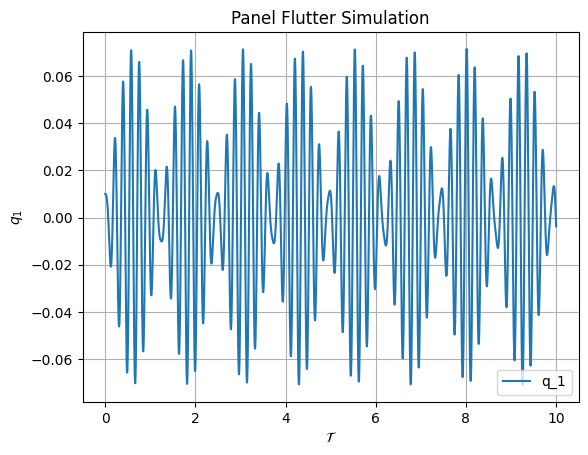

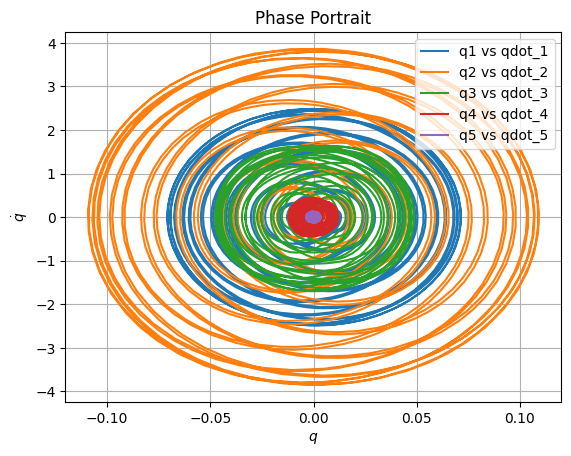

Running simulation for parameter set 2 with zeta_1 = 0.01


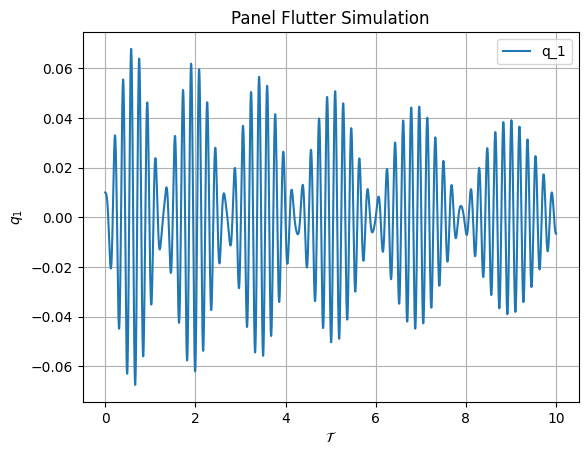

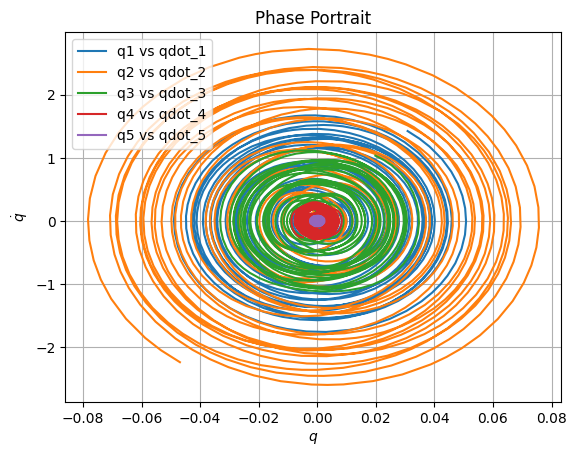

In [50]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Reproduce case from paper 

# Run with th = 0.005
thesis_case_1 = setup_parameters(lam=312.3, N=6,zeta_1=0.0, M_inf=25)
thesis_case_2 = setup_parameters(lam=312.3, N=6,zeta_1=0.01, M_inf=25)
thesis_cases = [thesis_case_1, thesis_case_2]

params = [thesis_case_1, thesis_case_2]
for i, param in enumerate(params):
    print(f"Running simulation for parameter set {i+1} with zeta_1 = {param['zeta_1']}")    
    y0 = np.zeros(2*param['N']) # Initial conditions (q_n and qdot_n)
    y0[0] = 0.01 # Initial condition for q_1

    sol = solve_ivp(flutter_model, [0,10], y0, args=(param,))
    plt.plot(sol.t, sol.y[0,:], label='q_1')
    # plt.plot(sol.t, sol.y[1,:], label='q_2')
    # plt.plot(sol.t, sol.y[2,:], label='q_3')
    # plt.plot(sol.t, sol.y[3,:], label='q_4')
    # plt.plot(sol.t, sol.y[4,:], label='q_5')
    plt.xlabel('$\mathcal{T}$')
    plt.ylabel('$q_1$')
    plt.title('Panel Flutter Simulation')
    plt.legend()
    plt.grid()
    plt.show()

    # Phase Portrait
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(sol.y[0,len(sol.t)//2:], sol.y[param['N'],len(sol.t)//2:], label='q1 vs qdot_1')
    ax.plot(sol.y[1,len(sol.t)//2:], sol.y[param['N']+1,len(sol.t)//2:], label='q2 vs qdot_2')
    ax.plot(sol.y[2,len(sol.t)//2:], sol.y[param['N']+2,len(sol.t)//2:], label='q3 vs qdot_3')
    ax.plot(sol.y[3,len(sol.t)//2:], sol.y[param['N']+3,len(sol.t)//2:], label='q4 vs qdot_4')
    ax.plot(sol.y[4,len(sol.t)//2:], sol.y[param['N']+4,len(sol.t)//2:], label='q5 vs qdot_5')   
    ax.set_xlabel('$q$')
    ax.set_ylabel('$\dot{q}$')
    ax.set_title('Phase Portrait')
    ax.legend()
    ax.grid()
    plt.show()

1.9433999999999998e-07
240.0
7764.051777261663
3560.4395604395604
2.8428187351199987e-05


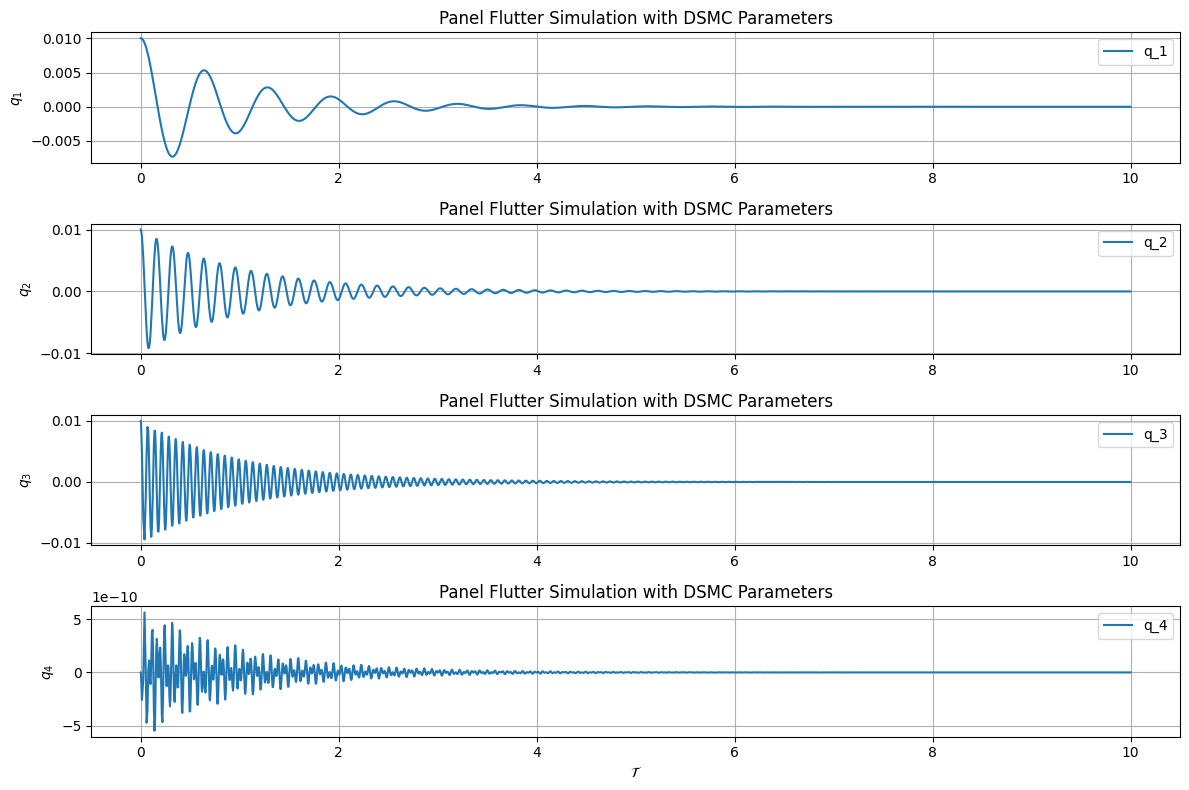

In [78]:
# Case to simulate with DSMC


def run_panel_flutter(params, y0, t_span=[0,10]):
    sol = solve_ivp(flutter_model, t_span, y0, args=(params,))
    return sol

# Change th to 0.01 and re-run

M_inf = 25
th = 0.01
mu = 2.37e-9
rho_solid = 8.2e3
rho_air = rho_solid * th * mu
T_p = 840
Theta = 3.5
T_air = T_p / Theta
R_air = 287.05
gamma = 1.4
c_air = np.sqrt(gamma * R_air * T_air)
u_air = M_inf * c_air
E = 1.8e11
a = 60e-2
h = a * th
nu = 0.3

D = E * h**3 / (12 * (1 - nu**2))
q = 1/2 * rho_air * u_air**2
lam = 2 * q * a**3 / (M_inf * D)

print(rho_air)
print(T_air)
print(u_air)
print(D)
print(lam)

dsmc_case = setup_parameters(lam=lam, th=th, N=6, zeta_1=0.1, M_inf=M_inf)
y0 = np.zeros(2*dsmc_case['N']) # Initial conditions (q_n and qdot_n)
y0[0] = 0.01 # Initial condition for q_1
y0[1] = 0.01
y0[2] = 0.01
t_span = [0, 10]
sol = run_panel_flutter(dsmc_case, y0, t_span)
plt.figure(figsize=(12,8))
for i in range(4):
    ax = plt.subplot(4,1,i+1)
    ax.plot(sol.t, sol.y[i,:], label=f'q_{i+1}')
    if i == 3:
        ax.set_xlabel('$\mathcal{T}$')
    ax.set_ylabel(f'$q_{i+1}$')
    ax.set_title('Panel Flutter Simulation with DSMC Parameters')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

# ax[0] = plt.subplot(411)
# ax[0].plot(sol.t, sol.y[0,:], label='q_1')
# ax[0].set_xlabel('$\mathcal{T}$')
# ax[0].set_ylabel('$q_1$')
# ax[0].set_title('Panel Flutter Simulation with DSMC Parameters')
# ax[0].legend()
# ax[0].grid()

# ax[1] = plt.subplot(412)
# ax[1].plot(sol.t, sol.y[1,:], label='q_2')
# ax[1].set_xlabel('$\mathcal{T}$')
# ax[1].set_ylabel('$q_2$')
# ax[1].set_title('Panel Flutter Simulation with DSMC Parameters')
# ax[1].legend()
# ax[1].grid()
# plt.show()


In [77]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

# Reconstruct the PDE solution from the modal coordinates in sol.
# The first N rows of sol.y are q_1 ... q_N; the next N rows are the time derivatives.
N = dsmc_case['N']
q_modes = sol.y[:N, :]  # shape: (N, len(sol.t))

# Use a smaller spatial grid for a fast preview.
x = np.linspace(0.0, 1.0, 160)
modes = np.arange(1, N + 1)[:, None]
basis = np.sin(modes * np.pi * x[None, :])
u_xt = q_modes.T @ basis  # shape: (len(sol.t), len(x))

# Subsample time frames so the animation renders quickly.
quick_preview = False
if quick_preview:
    frame_indices = np.unique(np.linspace(0, len(sol.t) - 1, min(120, len(sol.t))).astype(int))
else:
    frame_indices = np.arange(len(sol.t))
# frame_indices = np.unique(np.linspace(0, len(sol.t) - 1, min(60, len(sol.t))).astype(int))

print(frame_indices)
preview_u_xt = u_xt[frame_indices]
preview_t = sol.t[frame_indices]

fig, ax = plt.subplots(figsize=(8, 4.5))
line, = ax.plot([], [], lw=2)
time_text = ax.text(0.02, 0.92, '', transform=ax.transAxes)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(1.05 * np.min(preview_u_xt), 1.05 * np.max(preview_u_xt))
ax.set_xlabel('x')
ax.set_ylabel('PDE solution u(x, t)')
ax.set_title('Reconstructed Panel Flutter Solution')
ax.grid(True)


def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text


def update(frame_index):
    line.set_data(x, preview_u_xt[frame_index])
    time_text.set_text(f't = {preview_t[frame_index]:.3f}')
    return line, time_text

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    init_func=init,
    interval=60,
    blit=True,
)

# Fast path: show the preview inline immediately.
# display(HTML(anim.to_jshtml()))

# Optional export. Keep this False for quick figures; set True only when you want a file.
save_video = True
if save_video:
    out_dir = os.path.join(os.getcwd(), 'figures')
    os.makedirs(out_dir, exist_ok=True)
    mp4_path = os.path.join(out_dir, 'panel_flutter_reconstructed.mp4')
    gif_path = os.path.join(out_dir, 'panel_flutter_reconstructed.gif')

    try:
        if shutil.which('ffmpeg'):
            writer = animation.FFMpegWriter(fps=12, codec='libx264')
            anim.save(mp4_path, writer=writer, dpi=80)
            print(f'Saved animation to {mp4_path}')
        else:
            raise RuntimeError('ffmpeg not found')
    except Exception as exc:
        print(f'Could not save MP4 ({exc}); saving GIF instead.')
        writer = animation.PillowWriter(fps=12)
        anim.save(gif_path, writer=writer, dpi=80)
        print(f'Saved animation to {gif_path}')

plt.close(fig)

[   0    1    2 ... 2233 2234 2235]
Saved animation to /Users/kofiblake/Documents/DSMC-GPR/notebooks/figures/panel_flutter_reconstructed.mp4


In [42]:
import numpy as np

lam = 500
M_inf = 25
params = setup_parameters(lam=lam, N=6,zeta_1=0.1, M_inf=M_inf)
rho_solid = 8.2e3
rho_air = rho_solid * params['th'] * params['mu']
print(f"rho_air: {rho_air:e} kg/m^3")
m_air = 4.81e-26 # kg
n_air = rho_air / m_air # number density of air molecules at 110 km altitude
print(f"n_air: {n_air:e} molecules/m^3")

a = 0.01 # length (m)
T_p = 840 # temperature (K)

E = 1.8e11 # Young's modulus (Pa)
R_air = 287.05 # specific gas constant for air (J/kg/K)


# rho_solid = rho_air * 1/(params['th'] * params['mu'])
T_air = T_p / params['Theta']
h = a * params['th']
U_air = M_inf * np.sqrt(params['gamma'] * R_air * T_air)

flutter_param = 2 * (0.5 * rho_air * U_air**2) / (M_inf * E * h**3 / (12 * (1 - params['nu']**2))) * (a)**3


print(f"n_air: {n_air:e}")
print(f"T_air: {T_air:e}")
print(f"rho_air: {rho_air:e}")
print(f"U_air: {U_air:e}")
print(f"flutter_param: {flutter_param:e}")

D = E * h**3 / (12 * (1 - params['nu']**2))
T = 10
t = T / np.sqrt(D / (rho_solid * h * a**4))
print(f"Time scale: {t:e} seconds")

rho_air: 9.717000e-08 kg/m^3
n_air: 2.020166e+18 molecules/m^3
n_air: 2.020166e+18
T_air: 2.400000e+02
rho_air: 9.717000e-08
U_air: 7.764052e+03
flutter_param: 1.137127e-04
Time scale: 1.410626e-02 seconds
